In [10]:
import os
os.environ['PTNOLATEX']='1'
import sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

sys.path.insert(0, "/home/jysa/vdf-ml/externals/analysator")

import analysator as pt

In [35]:
t = 3408
VDFlim = 2e6
R_EARTH = 6.371e6

x_reconnection, y_reconnection, z_reconnection = -12, 0, 0
x_lobe, y_lobe, z_lobe = -12, 0, 3
coords = np.array([[x_reconnection*R_EARTH, y_reconnection*R_EARTH, z_reconnection*R_EARTH], 
                  [x_lobe*R_EARTH, y_lobe*R_EARTH, z_lobe*R_EARTH]])
labels = np.array([1, 0])
label_names = ["reconnection", "lobe"]

fileLocation = "/wrk-vakka/group/spacephysics/vlasiator/2D/BCH/bulk/"
bulkName = "bulk.000"+str(t)+".vlsv"
fileName = fileLocation + bulkName

file = pt.vlsvfile.VlsvReader(fileName)

In [34]:
def expr_velocity(exprmaps, requestvariables=False):

    if requestvariables == True:
        return ['rho', 'rho_v']

    rho = exprmaps['rho'][:,:]
    rhov = exprmaps['rho_v'][:,:,:]

    velocity = rhov / rho[:,:,None]

    return velocity

def extract_vdf(file,cid,box=-1, pop="avgs"):

    assert(cid>0)
    f = pt.vlsvfile.VlsvReader(file)
    # -- read phase space density
    vcells = f.read_velocity_cells(cid, pop)
    keys = list(vcells.keys())
    values = list(vcells.values())

    # -- generate a velocity space
    size = f.get_velocity_mesh_size(pop)
    vids = np.arange(4 * 4 * 4 * int(size[0]) * int(size[1]) * int(size[2]))

    # -- put phase space density into array
    dist = np.zeros_like(vids,dtype=float)
    dist[keys] = values

    # -- sort vspace by velocity
    v = f.get_velocity_cell_coordinates(vids, pop)

    i = np.argsort(v[:,0],kind='stable')
    v = v[i]
    #vids = vids[i]
    dist = dist[i]

    j = np.argsort(v[:,1],kind='stable')
    v = v[j]
    #vids = vids[j]
    dist = dist[j]

    k = np.argsort(v[:,2],kind='stable')
    v = v[k]
    #vids = vids[k]
    dist = dist[k]
    dist = dist.reshape(4*int(size[0]),4*int(size[1]),4*int(size[2]))
    vdf=dist
    i,j,k = np.unravel_index(np.argmax(vdf), vdf.shape)
    len=int(box)
    if box >0:
        data=vdf[(i-len):(i+len),(j-len):(j+len),(k-len):(k+len)]
    else:
        data =vdf 

    data=np.swapaxes(data,2,0)    
    return np.array(data,dtype=np.float32)



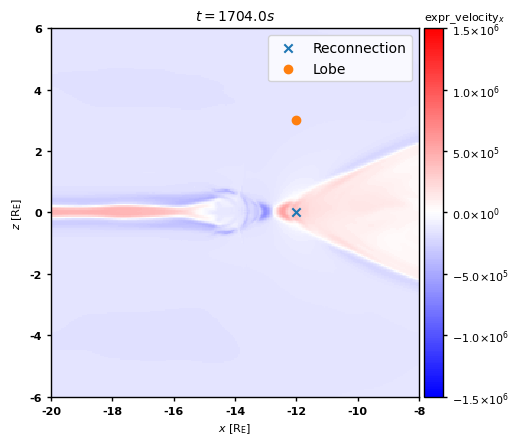

In [32]:
fig = plt.figure(figsize=(15,22))
ax1 = fig.add_subplot(411)

pt.plot.plot_colormap(filename=fileName,
                          axes=ax1,
                          boxre=[-20,-8,-6,6],
                          expression=expr_velocity , operator="x",
                          vmin=-1.5*1e+6,
                          vmax=1.5*1e+6,
                          )

ax1.scatter(x_reconnection, z_reconnection, marker="x", label="Reconnection")

ax1.scatter(x_lobe, z_lobe, marker="o", label="Lobe")

ax1.legend()



INFO: Getting offsets for population ion
INFO: V-space reduction via integration
INFO: Auto-switched to population 'avgs' for an old-style Vlasiator output
INFO: Found population avgs
INFO: 

INFO: cellid 3601751, x = -74850000.0, y = 0.0, z = 150000.0
INFO: Input velocity grid cell size 30000.0
INFO: Getting offsets for population avgs
INFO: Found 729792 v-space cells
INFO: Found a vlsv file MinValue of 8.301134972025815e-16
INFO: Dropping velocity cells under setThreshold value 8.301134972025815e-16
INFO: Performing slice with a counting thickness of 30000.0
INFO: Active f range is 2.490980114032101e-11 to 1.531902274302943e-07


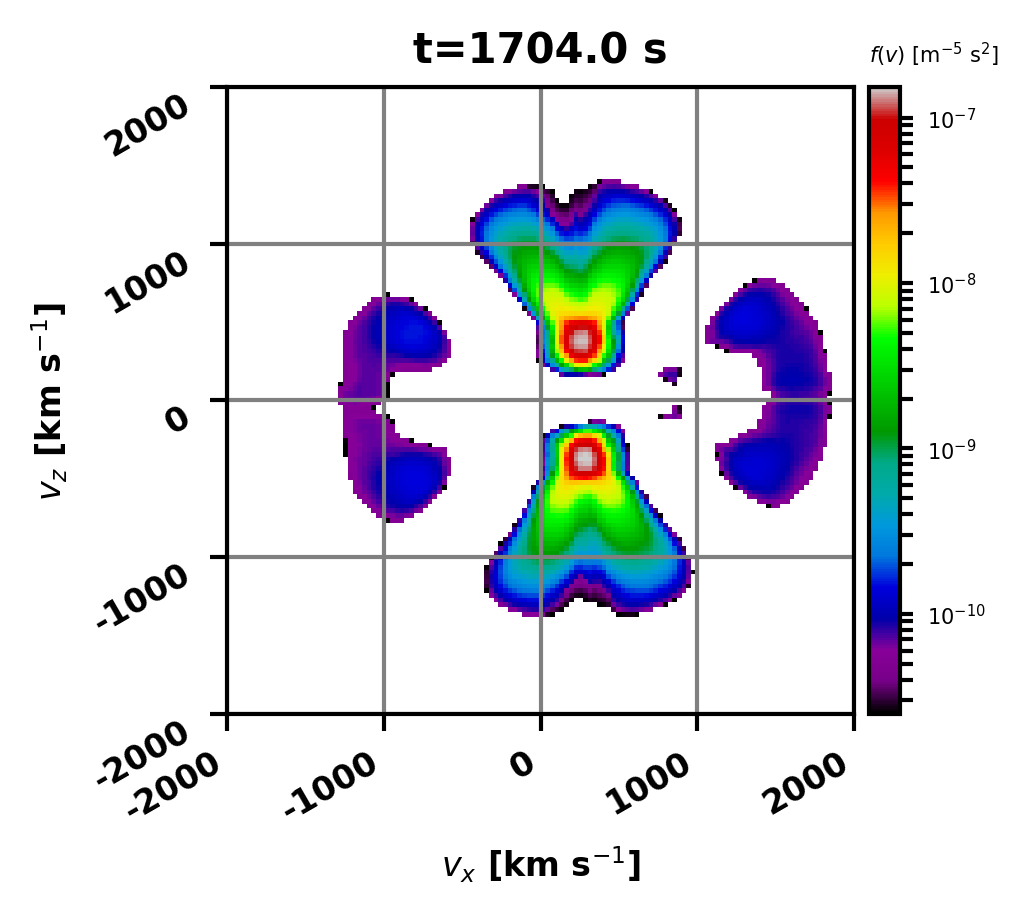

INFO: V-space reduction via integration
INFO: Auto-switched to population 'avgs' for an old-style Vlasiator output
INFO: Found population avgs
INFO: 

INFO: cellid 3751751, x = -74850000.0, y = 0.0, z = 15150000.0
INFO: Input velocity grid cell size 30000.0
INFO: Getting offsets for population avgs
INFO: Found 26624 v-space cells
INFO: Found a vlsv file MinValue of 2.9735100407476916e-16
INFO: Dropping velocity cells under setThreshold value 2.9735100407476916e-16
INFO: Performing slice with a counting thickness of 30000.0
INFO: Active f range is 9.528444883137647e-12 to 2.41805065553935e-07


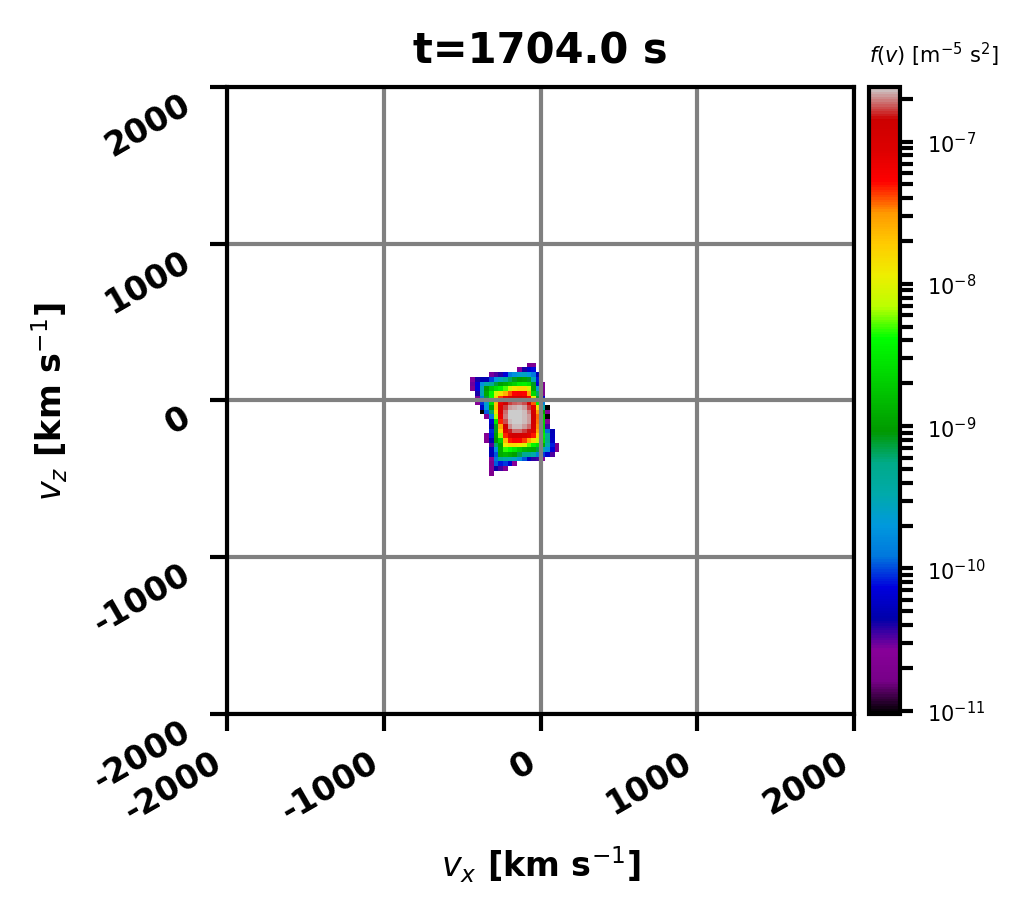

In [33]:
cids = []

for coord in coords:
    cid = file.get_cellid_with_vdf(coord, pop="ion")
    pt.plot.plot_vdf(filename=fileName,cellids=[cid],box=[-VDFlim,VDFlim,-VDFlim,VDFlim], colormap='nipy_spectral', xz=1, draw=1)
    cids.append(cid)

In [ ]:
X = []
y = []

for coord, label, label_name in zip(coords, labels, label_names):
    cid = file.get_cellid_with_vdf(coord, pop="ion")

    vdf = extract_vdf(
        fileName,
        cid=int(cid),
        )
    
    X.append(vdf)
    y.append(label)

X = np.stack(X).astype(np.float32)
y = np.array(y, dtype=np.int64)

INFO: Getting offsets for population ion
INFO: Getting offsets for population avgs
INFO: Found population avgs
INFO: Getting offsets for population avgs
INFO: Found population avgs


/home/jysa/vdf-ml/notebooks


In [37]:
project_root = Path.home() / "vdf-ml"
outdir = project_root / "data" / f"timestep_{int(t)}"
outdir.mkdir(parents=True, exist_ok=True)

In [38]:
np.savez_compressed(
    outdir / "vdfs.npz",
    X=X,
    y=y
)

In [41]:
data_dir = Path.home() / "vdf-ml" / "data" / f"timestep_{t}"

data = np.load(data_dir / "vdfs.npz")
X = data["X"]
y = data["y"]

print(X.shape)
print(y)

(2, 268, 268, 268)
[1 0]
